# 14章 アプリケーションとデータ転送

本章では、TCP/IPにおけるアプリケーション層について扱います。前章までは、通信トラフィックは「特に意味のないパケットを延々と送受信する」だけでしたが、実際にはそんなことはありません。インターネットのブラウジングでも、ファイルの送受信でも、HTTPやFTPなど具体的なプロトコルを用いて、意味のあるデータをパケットとして送受信します。本章では、このような代表的なプロトコルを簡易的に実装し、インターネットにおけるデータ転送について学習します。

## アプリケーション層

### プロトコルスタック再訪

OSI参照モデルでは最下位のレイヤ1が通信媒体を表す物理層、レイヤ2がMACアドレスを用いるデータリンク層、レイヤ3がIPアドレスを用いるネットワーク層、レイヤ4がTCPなどを扱うトランスポート層です。 TCP/IPでは、通信媒体とMACアドレスによる転送機能とを合わせてネットワークインタフェース層、IPアドレスを用いるのはネットワーク層、TCPやUDPが属するのはトランスポート層と呼びます。いずれにせよ、ここまでの層でパケットの転送機能が実現されますが、「どんなデータを送るか」といった中身すなわちアプリケーションについては規程されていませんでした。

実際に他のノードと通信をするときには、ファイルの送受信やデータのダウンロードなど、何らかの具体的な目的があります。
そのような具体的な機能を担うのが、OSI参照モデルの上位レイヤ（__アプリケーション層、プレゼンテーション層、セッション層__）およびTCP/IPにおけるアプリケーション層です。
本章では、このレイヤに該当する機能を扱っていきます。

### `ApplicationManager`クラスとリファクタリング

ここまで、`Node`クラスに対して様々な機能を実装してきました。その中には、ARPやIP、TCP/UDPのようなパケット転送機能のほかに、DNS機能やDHCPのようなアプリケーションプロトコルの動作も含まれていました。これに加えてFTPなどのアプリケーション機能も`Node`クラスに実装してしまうと`Node`クラスが肥大化し、またネットワーク層とアプリケーション層がごちゃ混ぜになり理解が困難になります。

そこで、アプリケーション層の動作をまとめて管理する仕組みとして`ApplicationManager`を作成し、Nodeクラスから呼び出す構造にします。つまり`Node`クラスはネットワークの基礎的な処理（__ARP、IPパケットの送受信、TCPの接続管理など__）を担当するようにし、DNSやDHCP、FTPなどの上位プロトコルは`ApplicationManager`経由で動作させるようにリファクタリングを実施します。

### ApplicationManager の役割

`DNSClient`, `DHCPClient`, `FTPClient`/`FTPServer` など各アプリケーションを登録し、Nodeから受け取ったパケットをどのアプリケーションに渡すか判断します。コネクションごとにどのアプリが紐づくかを管理する機能を持ち、対応するアプリケーションインスタンスを呼び出します。またアプリケーション同士の共通処理を一元管理できるようにします。`Node`クラスにDNSクエリの処理やDHCPリースの処理などを直接書くと、Nodeのコードが非常に複雑化します。TCP/IPの階層モデルをシミュレートする際、DNSやDHCPはアプリケーション層のプロトコルであり、本来Nodeの「ネットワーク層」的機能と独立して動作するものです。そこで`DNSClient`や`DHCPClient`などを、ApplicationManagerに登録して使う形へ整理すると、Node（__ネットワーク層的な機能__）とアプリケーション（__DNS/DHCPプロトコル__）を分離できます。

ただし、本章のターゲットはFTPやHTTPなどのアプリケーションプロトコルの学習であり、機能整理についての説明は煩雑でもあるので、ここでは上記のような概要を述べるにとどめます。つまり、ここではApplicationManagerの具体的な実装やリファクタリングの詳細についての説明は省略します。

## FTP

### FTPの概要

FTP（__File Transfer Protocol__）はTCP上で動作するファイル転送用のプロトコルです。クライアントとサーバの間でTCPコネクションを確立し、ファイルをパケットに分割して送ります。ネットワークアプリケーションの中でも最も基本的で重要な機能の一つとして、Webサイトのコンテンツアップロードやソフトウェアの配布などの用途で広く使われています。

FTPは典型的なクライアント・サーバモデルを採用しています：

1. **FTPサーバ**
   - ファイルを保管・管理
   - クライアントからの要求を待ち受け
   - アクセス制御とセキュリティ管理

2. **FTPクライアント**
   - サーバへの接続要求
   - ファイルのアップロード/ダウンロード
   - ユーザーインターフェースの提供

実際のFTPプロトコルは非常に複雑で、以下のような機能を持っています：
- 制御用とデータ転送用の2つのTCPコネクション
- 様々なファイル操作コマンド（GET, PUT, LIST等）
- バイナリ/テキストモードの転送
- 認証とアクセス制御

しかし、本シミュレータでは学習を容易にするため、以下のように簡略化しています：
- 1つのTCPコネクションでの通信
- 基本的なファイル取得（GET）のみをサポート
- シンプルなエラー処理
- 認証機能の省略

この簡略化により、ネットワークプロトコルの基本的な仕組みに焦点を当てて学習できます。

### `FTPClient`クラスの実装

このセクションでは、シミュレータにおけるFTPクライアントとサーバの実装について説明します。`FTPClient`クラスは、クライアント側のFTP機能を実装します。以下に主要な部分を示します：

```python
class FTPClient:
    def __init__(self, node, verbose=False):
        self.node = node  # ネットワークノードを保存
        self.app_manager = node.application_layer  # アプリケーションレイヤーのマネージャを取得
        self.verbose = verbose  # 詳細表示のフラグを保存
        self.state = "NOT_CONNECTED"  # 初期状態を「未接続」に設定
        self.file_to_retrieve = None  # 取得するファイル名を初期化
        self.outgoing_data = {}  # 送信データを保存する辞書を初期化
```

このコンストラクタでは：
- `node`: ネットワークノードへの参照
- `server_url`: 接続先FTPサーバのURL
- `verbose`: 詳細なログ出力の有無
- `state`: クライアントの状態管理
を初期化します。

#### 接続

接続処理は以下のメソッドで行われます。このメソッドを呼び出すことで、クライアントはサーバのIPアドレスとポート番号を使ってサーバへの接続を試みます。

まずクライアントの状態を「CONNECTING（接続中）」に変更し、クライアントは他の操作を行う前に接続が確立されるのを待つようになります。次に、指定されたサーバのIPアドレスとポート番号に対してTCPハンドシェイクを開始します。最後に、`self.app_manager.map_connection_to_app((server_ip, server_port), "FTP")`が実行されます。これは、確立しようとしている接続をFTPアプリケーションに関連付けるための処理です。具体的には、指定されたサーバのIPアドレスとポート番号の組み合わせを「FTP」というアプリケーションにマッピングすることで、この接続がFTP通信に使用されることを示します。

```python
    def connect(self, server_ip=None, server_url=None, server_port=21):
        """
        FTPサーバへの接続を開始します。server_ipが指定されていない場合はserver_urlを解決します。
        
        Parameters:
        - server_ip: FTPサーバのIPアドレス（オプション）。
        - server_port: FTPサーバのポート番号（デフォルトは21）。
        - server_url: 接続するFTPサーバのURL（オプション）。
        """
        # server_ipが指定されていれば、直接接続を試みる
        if server_ip:
            self._initiate_connection(server_ip, server_port)
        # server_urlが指定されていれば、DNS解決を行ってから接続を試みる
        elif server_url:
            self.server_url = server_url  # サーバURLを保存
            if self.verbose:
                print("[FTPClient] サーバURLからIPを解決しています:", server_url)
            
            def on_resolved(ip):
                if ip:
                    if self.verbose:
                        print("[FTPClient] 解決されたIP:", ip)
                    self._initiate_connection(ip, server_port)
                else:
                    if self.verbose:
                        print("[FTPClient] サーバURLの解決に失敗しました:", server_url)
            
            # ApplicationManagerを通じてサーバURLを解決
            resolved_ip = self.app_manager.resolve_destination_url(server_url, callback=on_resolved)
            if resolved_ip is not None:
                # すでに解決済みの場合は即座に接続を開始
                on_resolved(resolved_ip)
        else:
            if self.verbose:
                print("[FTPClient] 接続情報が不足しています。server_ipまたはserver_urlを指定してください。")
```

接続処理では：
1. サーバのIPアドレスとポート番号を保存
2. 状態を"CONNECTING"に設定
3. TCPハンドシェイクを開始
4. アプリケーションマネージャに接続を登録
という手順で実行されます。

#### パケット受信時の処理

`on_packet_received`メソッドは、FTPクライアントがサーバから送られてくるメッセージ（パケット）を受け取ったときに実行される重要な部分です。このメソッドの主な役割は、受信したメッセージの内容を解析し、現在のクライアントの状態に応じて適切な対応を行うことです。

まず、メソッドが呼び出されると、受信したパケットのペイロードをUTF-8形式でデコードします。次に、デコードされたデータの内容に基づいて処理が分岐します。FTPプロトコルでは、サーバからクライアントへの応答コードが特定の操作や状態を示します。このメソッドでは、受信したデータが特定の応答コードで始まるかどうかを確認し、それに応じて適切なコマンドをクライアントからサーバへ送信します。

- 220応答の処理: サーバからの「220 Service ready」というメッセージを受信すると、クライアントの状態を「LOGGED_OUT（ログアウト済み）」に変更し、匿名ユーザーとしてログインするために「USER anonymous」コマンドをサーバに送信します。

- 331応答の処理: サーバからの「331 User name okay, need password」というメッセージを受信すると、パスワードを送信するために「PASS anonymous@」コマンドをサーバに送信します。

- 230応答の処理: サーバからの「230 User logged in, proceed」というメッセージを受信すると、クライアントの状態を「LOGGED_IN（ログイン済み）」に変更します。さらに、もし取得したいファイル名が指定されていれば、「RETR ファイル名」コマンドをサーバに送信してファイルの取得を開始します。

- 150応答の処理: サーバからの「150 File status okay; about to open data connection」というメッセージを受信すると、ファイル転送の開始を意味します。この部分では、必要に応じてファイル転送の開始に伴う追加の処理を行うことができますが、現在のコードでは具体的な処理は行われていません。

- 226応答の処理: サーバからの「226 Closing data connection」というメッセージを受信すると、ファイル転送が完了したことを意味します。この部分でも、ファイル転送完了後の追加の処理を行うことができますが、現時点では具体的な処理は記述されていません。

このメソッドを通じて、FTPクライアントはサーバからの応答に応じて適切なコマンドを送信し、ログインプロセスやファイルの取得をスムーズに進めることができます。

```
    def on_packet_received(self, packet):
        """
        パケットを受信したときに呼び出されるハンドラ。
        
        Parameters:
        - packet: 受信したパケットのオブジェクト。
        """
        data = packet.payload.decode('utf-8', errors='ignore')  # パケットのペイロードをデコード
        if self.verbose:
            print("[FTPClient] 受信データ:", data.strip())

        # FTPの基本的なやり取りの流れに基づいて処理を行う
        if data.startswith("220"):
            # サーバからの220応答（サービス準備完了）
            self.state = "LOGGED_OUT"  # 状態を「ログアウト済み」に変更
            self.send_ftp_command("USER anonymous\r\n")  # ユーザー名を送信
        elif data.startswith("331"):
            # サーバからの331応答（パスワードが必要）
            self.send_ftp_command("PASS anonymous@\r\n")  # パスワードを送信
        elif data.startswith("230"):
            # サーバからの230応答（ログイン成功）
            self.state = "LOGGED_IN"  # 状態を「ログイン済み」に変更
            if self.file_to_retrieve:
                # 取得したいファイルが指定されていればRETRコマンドを送信
                self.send_ftp_command(f"RETR {self.file_to_retrieve}\r\n")
        elif data.startswith("150"):
            # サーバからの150応答（ファイル転送開始）
            # ファイル転送の開始に伴う処理をここで追加可能
            pass
        elif data.startswith("226"):
            # サーバからの226応答（転送完了）
            # ファイル転送完了後の処理をここで追加可能
            pass
```

#### FTPコマンド送信

`send_ftp_command`メソッドは、FTPクライアントがサーバに対して特定のFTPコマンドを送信するための機能を提供します。具体的には、以下の情報を基にデータを送信します：

- サーバのIPアドレス (self.server_ip): 送信先のFTPサーバのIPアドレスです。
- コマンドデータ (command.encode('utf-8')): 送信するFTPコマンドをUTF-8形式にエンコードしたバイト列です。例えば、「USER anonymous\r\n」や「PASS anonymous@\r\n」といったコマンドがここに該当します。
- プロトコル (protocol="TCP"): 使用する通信プロトコルを指定します。FTPは通常TCPを使用するため、ここではTCPが選ばれています。
- 送信先ポート (destination_port=self.server_port): 送信先のポート番号です。デフォルトでは21番ポートが使用されますが、必要に応じて変更することもできます。

このプロセスにより、FTPクライアントは指定されたコマンドをサーバに確実に送信することができます。例えば、ユーザー名を送信する「USER anonymous\r\n」や、パスワードを送信する「PASS anonymous@\r\n」といったコマンドがサーバに送られ、サーバはそれに応じて適切な応答を返します。

```
    def send_ftp_command(self, command):
        """
        FTPコマンドをサーバに送信します。
        
        Parameters:
        - command: 送信するFTPコマンドの文字列。
        """
        if self.verbose:
            print("[FTPClient] 送信コマンド:", command.strip())
        # サーバIPとポートを指定してデータを送信
        self.node.send_app_data(
            self.server_ip,
            command.encode('utf-8'),  # コマンドをバイト列にエンコード
            protocol="TCP",  # プロトコルをTCPに指定
            destination_port=self.server_port  # 送信先ポートを指定
        )
```

### `FTPServer`クラスの実装

`FTPServer`クラスは、サーバ側のFTP機能を実装します：

```python
class FTPServer:
    def __init__(self, node, shared_files, verbose=False):
        self.node = node
        self.app_manager = node.application_layer  
        self.shared_files = shared_files
        self.verbose = verbose
        self.state = "READY"
```

サーバの初期化では：
- `shared_files`: 共有するファイルのディクショナリ
- `state`: サーバの状態管理
などを設定します。

#### 接続

クライアントとのTCP接続を確立した後で、サービス準備が完了したことをクライアント側へと伝えます。具体的には、まず接続に関連するトラフィック情報を設定します。これは、データの送受信や転送の進捗を管理するために必要な情報です。次に、接続元のクライアントのIPアドレスとポート番号を取得し、サーバ側のFTP制御ポート（通常は21番ポート）を指定します。

その後、もし詳細なログ表示が有効になっていれば、コンソールに「接続が確立しました。220挨拶を送信します。」というメッセージが表示されます。これは、デバッグや監視の際に役立つ情報です。

最後に、クライアントに対して「220 Service ready」というメッセージを送信します。これは、FTPプロトコルにおいてサーバが正常に動作しており、クライアントからのコマンドを受け付ける準備ができていることを示す標準的な挨拶メッセージです。このメッセージを送信した後、サーバの状態を「ユーザー待ち」（WAIT_USER）に変更します。これにより、サーバは次にクライアントからユーザー名を送信されるのを待つ状態になります。

```
    def on_connection_established(self, connection_key):
        """
        TCP接続が確立したときに呼び出されるハンドラ。
        
        Parameters:
        - connection_key: 接続を一意に識別するキー（クライアントIPとクライアントポートのタプル）。
        """
        self.set_traffic_info(connection_key)  # トラフィック情報を設定
        client_ip, client_port = connection_key  # クライアントのIPとポートを取得
        server_port = 21  # FTP制御ポートは通常21
        if self.verbose:
            print("[FTPServer] 接続が確立しました。220挨拶を送信します。")
        # サーバの220サービス準備完了メッセージをクライアントに送信
        self.send_ftp_response(client_ip, client_port, server_port, "220 Service ready\r\n")
        self.state = "WAIT_USER"  # 状態を「ユーザー待ち」に変更
```

#### パケット受信時の処理

パケット受信した際には、自身の状態とパケット内のコマンドに応じた処理を実施します。具体的には、まずクライアントから送られてきたデータを文字列として読み取ります。サーバの現在の状態が「ユーザー待ち」（WAIT_USER）の場合、クライアントが送信したユーザー名（USERコマンド）を受け取ると、「331 User name okay, need password.」というメッセージを返します。次に、クライアントがパスワード（PASSコマンド）を送信すると、「230 User logged in, proceed.」というメッセージを返し、サーバの状態を「ログイン済み」（LOGGED_IN）に変更します。

状態が「ログイン済み」になった後、クライアントがファイルの取得を要求するRETRコマンドを送信すると、サーバは指定されたファイルが存在するかを確認します。ファイルが見つかれば、「150 File status okay; about to open data connection.」というメッセージを返し、ファイルの送信を開始します。もし指定されたファイルが存在しない場合は、「550 File not found.」というエラーメッセージを返します。

また、クライアントからのコマンドに誤りがあった場合や必要な引数が不足している場合には、「501 Syntax error in parameters or arguments.」といった適切なエラーメッセージを返すことで、クライアントに問題を知らせます。

```python
    def on_packet_received(self, packet):
        """
        パケットを受信したときに呼び出されるハンドラ。
        
        Parameters:
        - packet: 受信したパケットのオブジェクト。
        """
        data = packet.payload.decode('utf-8', errors='ignore')  # パケットのペイロードをデコード
        if self.verbose:
            print("[FTPServer] 受信データ:", data.strip())

        # パケットの送信元IP、ポート、送信先ポートを取得
        client_ip = packet.header["source_ip"]
        client_port = packet.header["source_port"]
        server_port = packet.header["destination_port"]
        connection_key = (client_ip, client_port)  # 接続キーを作成

        # 現在のサーバの状態に基づいて処理を分岐
        if self.state == "WAIT_USER":
            # ユーザー名を待っている状態
            if data.startswith("USER"):
                # クライアントからUSERコマンドが送られてきた場合
                self.send_ftp_response(client_ip, client_port, server_port, "331 User name okay, need password.\r\n")
            elif data.startswith("PASS"):
                # クライアントからPASSコマンドが送られてきた場合
                self.send_ftp_response(client_ip, client_port, server_port, "230 User logged in, proceed.\r\n")
                self.state = "LOGGED_IN"  # 状態を「ログイン済み」に変更

        elif self.state == "LOGGED_IN":
            # ログインが完了した状態
            if data.startswith("RETR"):
                # クライアントからRETRコマンド（ファイル取得要求）が送られてきた場合
                parts = data.strip().split(" ", 1)  # コマンドと引数に分割
                if len(parts) < 2:
                    # 引数が不足している場合はエラーを返す
                    self.send_ftp_response(client_ip, client_port, server_port, "501 Syntax error in parameters or arguments.\r\n")
                    return
                filename = parts[1]  # 取得したいファイル名を取得
                file_data = self.shared_files.get(filename, None)  # 共有ファイルからデータを取得
                if file_data is None:
                    # ファイルが存在しない場合はエラーを返す
                    self.send_ftp_response(client_ip, client_port, server_port, "550 File not found.\r\n")
                    return
                
                file_size = len(file_data)  # ファイルサイズを取得
                transfer_info = {
                    'end_time': self.node.network_event_scheduler.current_time + 3600,  # 転送終了時間を現在時刻から1時間後に設定
                    'payload_size': 1460,  # 1回あたりのペイロードサイズを設定（例: 1460バイト）
                    'bytes_transferred': 0,  # 転送済みバイト数を初期化
                    'progress': [],  # 転送の進捗を記録するリストを初期化
                    'file_size': file_size,  # ファイルサイズを設定
                    'transfer_done': False  # 転送完了フラグを初期化
                }

                # Node側のtransfer_infoに転送情報を設定
                self.node.tcp_connections[connection_key]['transfer_info'] = transfer_info
                self.outgoing_data[connection_key] = file_data  # 送信するファイルデータを保存

                # サーバから150応答（ファイル転送開始）をクライアントに送信
                self.send_ftp_response(client_ip, client_port, server_port, "150 File status okay; about to open data connection.\r\n")
                # ファイルの最初のチャンクを送信
                self.send_next_chunk(connection_key, client_ip, client_port, server_port)

```

まとめると、ファイル転送処理では：

1. クライアントからのRETRコマンドを受信
2. 要求されたファイルの存在確認
3. 転送情報の初期化
4. ファイルデータの準備

という手順で実行されます。



## FTPの動作確認

このセクションでは、実際にFTPクライアントとサーバを使用してファイル転送を行う方法を説明します。

### 基本的なセットアップ

まず、FTPサーバとクライアントの設定を行います：

```python
### FTPサーバの設定
shared_files = {
    "example.txt": b"Hello, this is a test file content!",
    "data.bin": b"Binary file content example"
}
ftp_server = FTPServer(node2, shared_files, verbose=True)

### FTPクライアントの設定
ftp_client = FTPClient(node1, verbose=True)
```

この例では：
- サーバ側で2つのファイル（example.txt と data.bin）を共有するように設定
- verboseモードを有効にして、詳細なログを出力するように設定

### ファイル転送の実行

FTPクライアントからサーバへの接続とファイル転送は以下のように行います：

```python
### サーバへの接続
ftp_client.connect("192.168.2.1", 21)

### ファイルの取得
ftp_client.retrieve_file("example.txt")
```

### 実行結果の例

以下は、FTPクライアントとサーバ間でファイル転送を行った際のログ出力例です：

```
[FTPClient] Requesting TCP connect to 192.168.2.1 21
[FTPClient] Connection established. Waiting for server greeting (220)...
[FTPServer] Connection established. Sending 220 greeting.
[FTPServer] Sending response: 220 Service ready
[FTPClient] Received: 220 Service ready
[FTPClient] Sending command: USER anonymous
[FTPServer] Received: USER anonymous
[FTPServer] Sending response: 331 User name okay, need password.
[FTPClient] Received: 331 User name okay, need password.
[FTPClient] Sending command: PASS anonymous@
[FTPServer] Received: PASS anonymous@
[FTPServer] Sending response: 230 User logged in, proceed.
[FTPClient] Received: 230 User logged in, proceed.
[FTPClient] Sending command: RETR example.txt
[FTPServer] Received: RETR example.txt
[FTPServer] Sending response: 150 File status okay; about to open data connection.
[FTPServer] Transfer complete. Sent 226 response.
```

### 動作の解説

1. **接続の確立**:
   - クライアントがサーバに接続要求を送信
   - サーバが応答して接続を受け入れ

2. **認証プロセス**:
   - クライアントが匿名ユーザとしてログイン
   - サーバが認証を受け入れ

3. **ファイル転送**:
   - クライアントがRETRコマンドでファイルを要求
   - サーバがファイルを送信
   - 転送完了後に確認メッセージを送信

このように、FTPクライアントとサーバ間でファイル転送が行われる様子を確認できます。verboseモードを使用することで、通信の詳細な流れを理解することができます。

Cloning into 'network-simulator'...
remote: Enumerating objects: 2813, done.
remote: Counting objects: 100% (875/875), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 2813 (delta 808), reused 792 (delta 764), pack-reused 1938 (from 2)
Receiving objects: 100% (2813/2813), 3.88 MiB | 7.83 MiB/s, done.
Resolving deltas: 100% (2072/2072), done.
/content/network-simulator/network-simulator/network-simulator


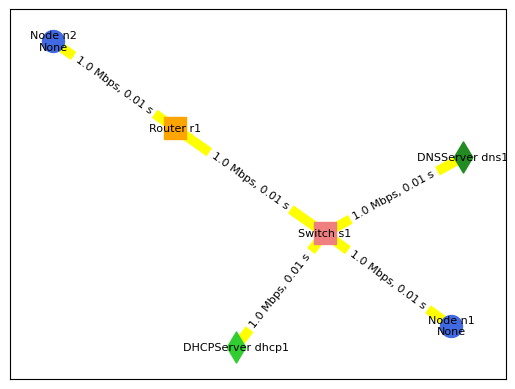

Node n1 sending DHCP DISCOVER (attempt 1/3)
[LINK] n1 sent packet to s1 at 0.532383
DHCP Server dhcp1 offering IP 192.168.1.1/24 to client 55:ee:32:9f:54:2f
Node n1 sending DHCP REQUEST for IP 192.168.1.1/24
[LINK] n1 sent packet to s1 at 0.580063
Node n1 has been assigned the IP address 192.168.1.1/24.
Node n1 has been assigned the DNS server IP address 192.168.1.200/24.
Node n1 sending DNS query for www.example.com
[LINK] n1 sent packet to s1 at 1.000000
DNS resolved: www.example.com -> 192.168.2.1/24
Initiating TCP handshake: Sending SYN to 192.168.2.1/24:21
[LINK] n1 sent packet to s1 at 1.040000
Sending TCP packet to 192.168.2.1/24:21 Flags: SYN Seq:None Ack:None
[LINK] n1 sent packet to s1 at 1.081792
[LINK] n2 sent packet to r1 at 1.112880
Processing TCP packet from 192.168.1.1/24:1024 to 192.168.2.1/24:21
TCP flags: SYN
[LINK] n2 sent packet to r1 at 1.133648
Sending TCP packet to 192.168.1.1/24:1024 Flags: SYN,ACK Seq:None Ack:None
[LINK] n2 sent packet to r1 at 1.154544
[LINK

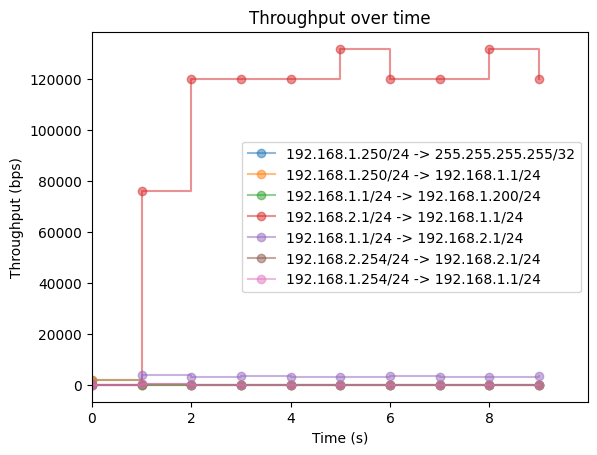

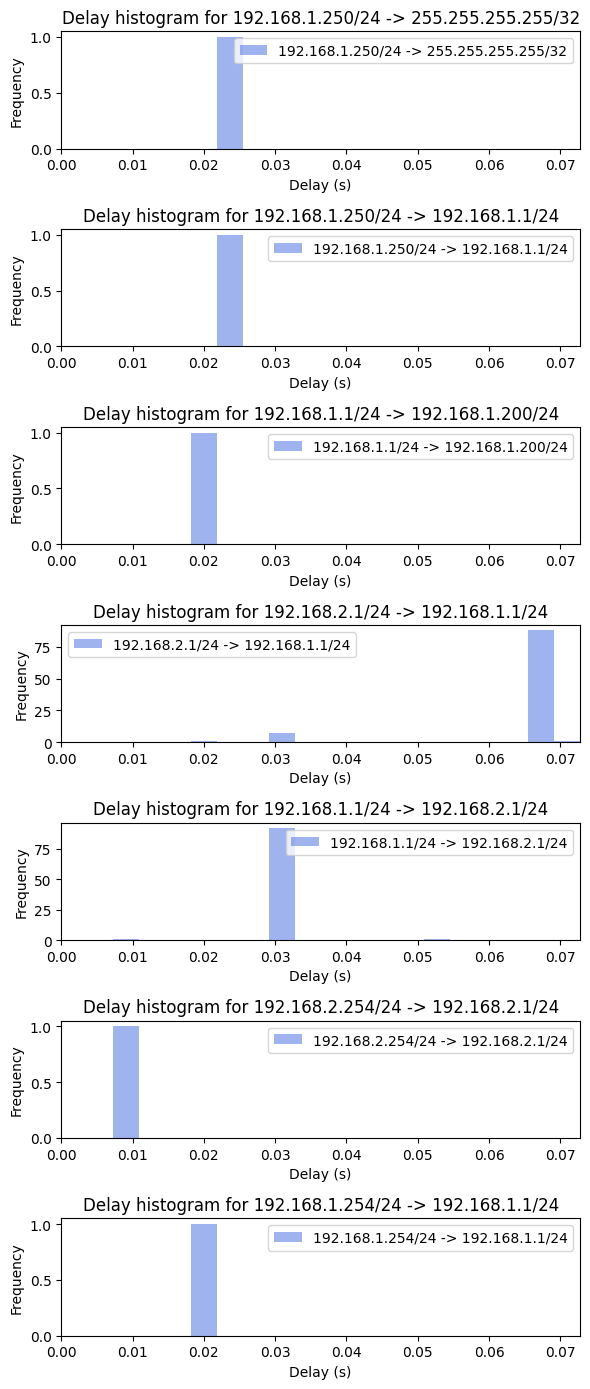

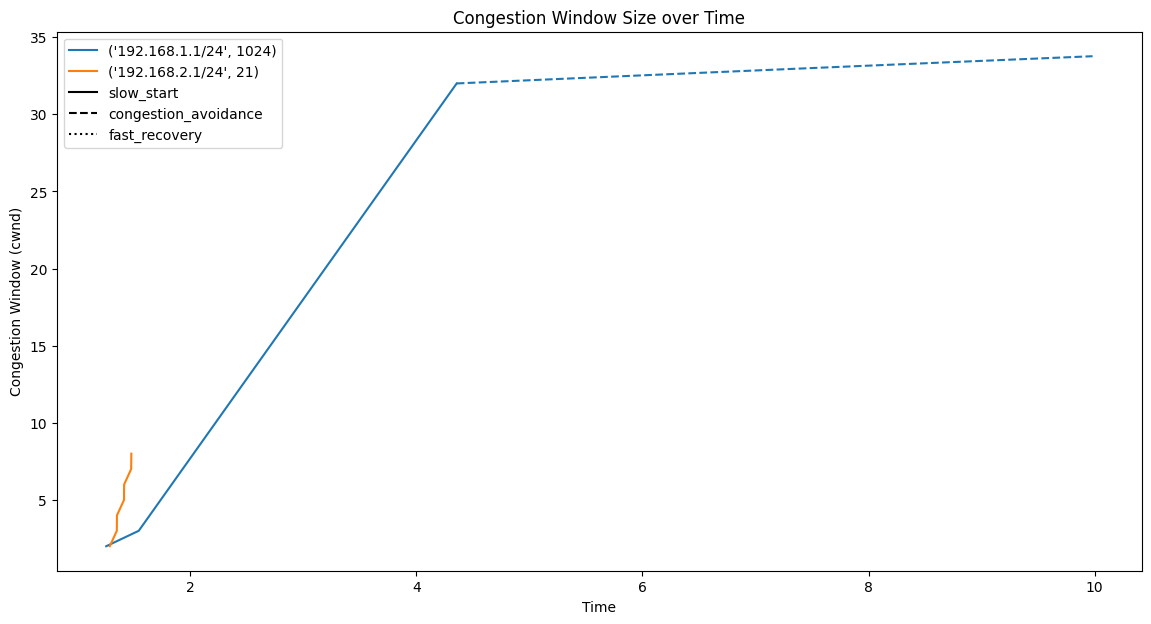

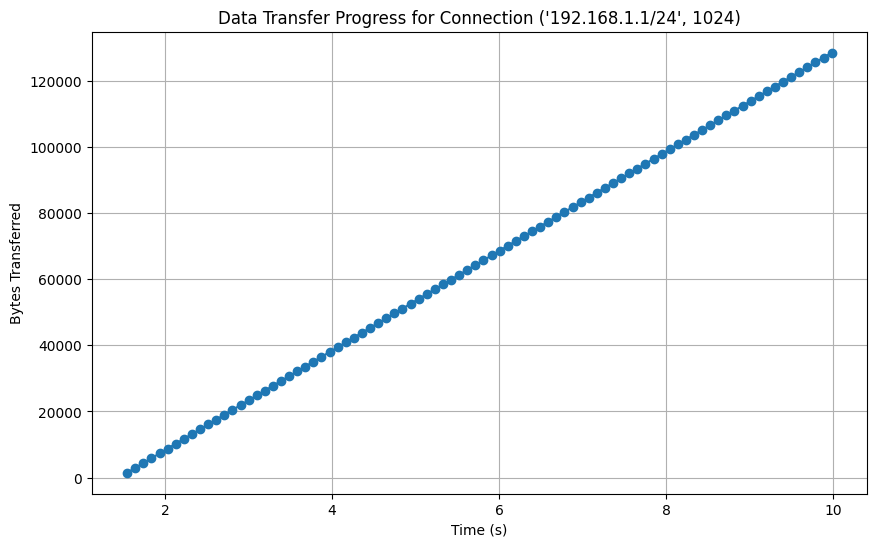

In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')
%cd network-simulator

from sec14a.NetworkEventScheduler import NetworkEventScheduler
from sec14a.Node import Node
from sec14a.Switch import Switch
from sec14a.Router import Router
from sec14a.Server import DNSServer, DHCPServer
from sec14a.Link import Link
from sec14a.Application import DnsClient, DhcpClient, UDPApp, FTPClient, FTPServer

nes = NetworkEventScheduler(seed=7, log_enabled=True, verbose=False, tcp_verbose=True, link_verbose=False)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.0/24", network_event_scheduler=nes)  # DHCP利用
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)  # IPアドレスを静的に設定
switch1 = Switch(node_id="s1", ip_address="192.168.1.240/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "192.168.2.254/24"], network_event_scheduler=nes)
dns1 = DNSServer(node_id="dns1", ip_address="192.168.1.200/24", network_event_scheduler=nes)
dhcp1 = DHCPServer(node_id="dhcp1", ip_address="192.168.1.250/24", dns_server_ip="192.168.1.200/24", start_cidr="192.168.1.0/24", network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=1000000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=1000000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(dns1, switch1, bandwidth=1000000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(dhcp1, switch1, bandwidth=1000000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link5 = Link(node2, router1, bandwidth=1000000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# DNSサーバに対してDNSレコード設定
dns1.add_dns_record("www.example.com", "192.168.2.1/24")

# DHCPサーバに対して使用済みIPアドレス登録
used_ips = ["192.168.1.240/24", "192.168.1.254/24", "192.168.1.200/24", "192.168.1.250/24"]
dhcp1.mark_ips_as_used(used_ips)

# FTPトラフィック設定
ftp_server = FTPServer(node2, shared_files={}, verbose=True)  # FTPサーバインスタンス
node2.register_application(21, "TCP", ftp_server)  # 21/TCPポートでFTPサーバを起動（待ち受け）
ftp_client = FTPClient(node1, verbose=False)  # FTPクライアントインスタンス
node1.register_application(0, "TCP", ftp_client)  # FTPクライアントをApplicationManagerに登録

# ファイル読み込み（サーバ側ファイル想定）
file_path = 'data/cat.jpg'
with open(file_path, 'rb') as f:
    file_data = f.read()
ftp_server.shared_files["cat.jpg"] = file_data  # サーバにファイル登録

# クライアント側でFTP転送を開始する処理
def start_ftp_transfer():
    ftp_client.connect(server_url="www.example.com", server_port=21)
    ftp_client.retrieve_file("cat.jpg")
nes.schedule_event(1.0, start_ftp_transfer)

# UDP送信アプリケーションのインスタンス作成
#udp_app = UDPApp(node1)
#def start_udp_traffic():
#    udp_app.start_traffic(destination_url="www.example.com", bitrate=100000, start_time=2.0, duration=5.0, header_size=28, payload_size=1000, burstiness=1.0, dscp=16)
#nes.schedule_event(2.0, start_udp_traffic)

# イベントスケジューラを実行
nes.run_until(10.0)

# フォワーディングテーブルやルーティングテーブルを確認
node1.print_arp_table()
node1.print_url_to_ip_mapping()
node1.print_tcp_connections()
router1.print_arp_table()
router1.print_routing_table()
node2.print_arp_table()
node2.print_tcp_connections()

# 結果を確認
nes.generate_summary(nes.packet_logs)
nes.generate_throughput_graph(nes.packet_logs)
nes.generate_delay_histogram(nes.packet_logs)

# 転送進行状況のプロット
nes.plot_cwnd_log()
ftp_connections = [ck for ck, info in node2.tcp_connections.items() if info.get('transfer_info') and info['transfer_info'].get('progress')]
if ftp_connections:
    connection_key = ftp_connections[0]
    nes.plot_transfer_progress(node2, connection_key)

## HTTP

### HTTPの基本的な仕組み

HTTPは、ウェブブラウザとウェブサーバの間でファイルをやり取りするための基本的な通信プロトコルです。このセクションでは、シンプルなHTTPクライアントとサーバを実装し、ファイル転送の基本的な仕組みを学びます。具体的には、Application.pyファイル内のHTTPClientクラスとHTTPServerクラスを使用して実装を行います。

まず、クライアント-サーバモデルについて説明します。HTTPクライアント、例えばウェブブラウザがサーバに対してリクエストを送信します。サーバはそのリクエストを受け取り、内容を処理して適切なレスポンスをクライアントに返します。これにより、クライアントはウェブページやファイルを取得することができます。

次に、HTTPリクエストの構造についてです。リクエストはリクエストラインから始まり、ここにはメソッド、パス、そしてHTTPのバージョンが含まれます。例えば、「GET /index.html HTTP/1.0」というリクエストラインは、index.htmlというファイルを取得するためのリクエストを示しています。このリクエストラインの後には、必要に応じてヘッダー情報が続くことがありますが、基本的な部分はこのリクエストラインです。

続いて、HTTPレスポンスの構造について説明します。レスポンスはステータスラインから始まり、ここにはHTTPのバージョン、ステータスコード、そしてその説明が含まれます。例えば、「HTTP/1.0 200 OK」というステータスラインは、リクエストが成功し、要求された内容が問題なく返されたことを示しています。このステータスラインの後には、レスポンスヘッダーや実際のデータ（例えばHTMLファイルの内容）が続きます。

最後に、主なステータスコードについてです。200 OKはリクエストが正常に処理されたことを意味し、クライアントは要求したファイルを受け取ることができます。一方、404 Not Foundは要求されたファイルがサーバに存在しないことを示します。また、400 Bad Requestはリクエストの形式に誤りがある場合に返されます。これらのステータスコードを理解することで、クライアントとサーバ間の通信がスムーズに行われるようになります。

### HTTPClientクラスの実装

まず、クライアント側のクラスを実装します。

```python
class HTTPClient:
    def __init__(self, node, server_url=None, verbose=False):
        """
        HTTPClientクラスのコンストラクタ。
        
        Parameters:
        - node: ネットワークノードのインスタンス。
        - server_url: 接続するHTTPサーバのURL（オプション）。
        - verbose: 詳細なログを表示するかどうかのフラグ。
        """
        self.node = node  # ネットワークノードを保存
        self.app_manager = node.application_layer  # アプリケーションレイヤーのマネージャを取得
        self.server_url = server_url  # サーバURLを保存
        self.verbose = verbose  # 詳細表示のフラグを保存
        self.state = "NOT_CONNECTED"  # 初期状態を「未接続」に設定
        self.file_to_retrieve = None  # 取得するファイル名を初期化
        self.response_data = {}  # 受信したレスポンスデータを保存する辞書を初期化
```

#### 接続

`connect`メソッドは、HTTPクライアントが指定されたHTTPサーバに接続を開始するための機能を提供します。まず、引数として渡されたサーバのIPアドレス（server_ip）とポート番号（server_port、デフォルトは80番）をクラスの属性として保存します。その後、クライアントの状態を「CONNECTING（接続中）」に変更します。これは、現在接続の試行中であることを示すための内部的なフラグです。この状態変更により、クライアントは他の操作を行う前に接続が確立されるのを待つようになります。

次に、`self.node.initiate_tcp_handshake(server_ip, server_port)`が呼び出されます。これは、指定されたサーバのIPアドレスとポート番号に対してTCPハンドシェイクを開始する関数です。TCPハンドシェイクは、クライアントとサーバ間で信頼できる接続を確立するための初期通信プロセスです。このプロセスが成功すると、クライアントとサーバはデータを安全にやり取りできるようになります。

最後に、`self.app_manager.map_connection_to_app((server_ip, server_port), "HTTP")`が実行されます。これは、確立しようとしている接続をHTTPアプリケーションに関連付けるための処理です。具体的には、指定されたサーバのIPアドレスとポート番号の組み合わせを「HTTP」というアプリケーションにマッピングすることで、この接続がHTTP通信に使用されることを示します。これにより、後続のデータ送受信が正しくHTTPプロトコルに従って行われるようになります。

```
   def connect(self, server_ip, server_port=80):
        """
        HTTPサーバへの接続を開始します。
        
        Parameters:
        - server_ip: HTTPサーバのIPアドレス。
        - server_port: HTTPサーバのポート番号（デフォルトは80）。
        """
        if self.verbose:
            print("[HTTPClient] TCP接続を要求しています:", server_ip, server_port)
        self.server_ip = server_ip  # サーバのIPアドレスを保存
        self.server_port = server_port  # サーバのポート番号を保存
        self.state = "CONNECTING"  # 状態を「接続中」に変更
        self.node.initiate_tcp_handshake(server_ip, server_port)  # TCPハンドシェイクを開始
        self.app_manager.map_connection_to_app((server_ip, server_port), "HTTP")  # 接続をHTTPアプリケーションにマッピング
```

#### ファイル取得

`get_file`メソッドは、HTTPクライアントが指定されたファイルをサーバから取得するために使用されます。まず取得したいファイルの名前（__filename__）がクラスの属性file_to_retrieveに保存されます。

次に、クライアントの現在の状態が「CONNECTED」（接続済み）であるかどうかを確認します。状態が「CONNECTED」であれば、すでにサーバとの接続が確立されているため、即座にHTTP GETリクエストを送信します。具体的には、send_http_requestメソッドを呼び出し、GET /{filename} HTTP/1.0\r\n\r\nというリクエストをサーバに送信します。このリクエストは、HTTP/1.0プロトコルを使用して指定されたファイルを要求するものです。リクエストの末尾にある空行（\r\n\r\n）は、リクエストヘッダーの終了を示すために必要です。

一方、現在の状態が「CONNECTED」でない場合、つまりまだサーバとの接続が確立されていない場合は、ファイルの取得リクエストをすぐに送信することができません。そこで、verboseフラグがTrueに設定されている場合、コンソールに「接続後にファイルを取得します」といったメッセージが表示されます。これは、後で接続が確立された際にファイルを取得する準備ができていることを示すための情報です。実際のリクエスト送信は、接続が確立された後にon_connection_establishedメソッド内で行われます。

```
    def get_file(self, filename):
        """
        指定されたファイルを取得するリクエストを送信します。
        
        Parameters:
        - filename: 取得するファイルの名前。
        """
        self.file_to_retrieve = filename  # 取得するファイル名を保存
        if self.state == "CONNECTED":
            # 既に接続が確立されている場合は即座にGETリクエストを送信
            self.send_http_request(f"GET /{filename} HTTP/1.0\r\n\r\n")
        elif self.verbose:
            # 接続がまだ確立されていない場合は、接続後にファイルを取得することをログに記録
            print("[HTTPClient] 接続後にファイルを取得します:", filename)
```

#### HTTPリクエスト

`send_http_request`メソッドは、HTTPクライアントがサーバに対して特定のHTTPリクエストを送信するための機能を提供します。このメソッドを使用することで、クライアントはサーバに対してファイルの取得要求やその他のHTTP操作を指示することができます。

メソッドが実行されると、`self.node.send_app_data`関数が呼び出されます。この関数は、実際にデータをサーバに送信する役割を担っています。具体的には、以下の情報を基にデータが送信されます：

- サーバのIPアドレス (self.server_ip): 送信先となるHTTPサーバのIPアドレスです。
- リクエストデータ (request.encode('utf-8')): 送信するHTTPリクエストをUTF-8形式にエンコードしたバイト列です。例えば、「GET /index.html HTTP/1.0\r\n\r\n」といったリクエストがここに該当します。
- プロトコル (protocol="TCP"): 使用する通信プロトコルを指定します。HTTPは通常TCPを使用するため、ここではTCPが選ばれています。
- 送信先ポート (destination_port=self.server_port): 送信先のポート番号です。デフォルトでは80番ポートが使用されますが、必要に応じて変更することもできます。

このプロセスにより、HTTPクライアントは指定されたリクエストをサーバに確実に送信することができます。例えば、特定のファイルを取得するための「GET」リクエストや、サーバのステータスを確認するための「HEAD」リクエストなどがサーバに送られ、サーバはそれに応じたレスポンスを返します。


```
    def send_http_request(self, request):
        """
        HTTPリクエストをサーバに送信します。
        
        Parameters:
        - request: 送信するHTTPリクエストの文字列。
        """
        if self.verbose:
            print("[HTTPClient] 送信リクエスト:", request.strip())
        # サーバIPとポートを指定してデータを送信
        self.node.send_app_data(
            self.server_ip,  # サーバのIPアドレス
            request.encode('utf-8'),  # リクエストをバイト列にエンコード
            protocol="TCP",  # プロトコルをTCPに指定
            destination_port=self.server_port  # 送信先ポートを指定
        )
```

### HTTPServerクラスの実装

次に、サーバ側クラスを実装します。

```python
class HTTPServer:
    def __init__(self, node, shared_files, verbose=False):
        self.node = node
        self.app_manager = node.application_layer
        self.shared_files = shared_files
        self.verbose = verbose
        self.state = "READY"
```

#### 接続

`on_connection_established`メソッドは、HTTPサーバがクライアントとの新しいTCP接続を確立したときに呼び出されます。このメソッドの主な役割は、接続が確立されたことを認識し、サーバの状態を適切に更新することです。

具体的には、まずサーバの内部状態を「READY」に設定します。サーバは新たに接続されたクライアントからのリクエストを受け付ける準備ができていることを示します。

```
    def on_connection_established(self, connection_key):
        """
        TCP接続が確立したときに呼び出されるハンドラ。
        
        Parameters:
        - connection_key: 接続を一意に識別するキー（クライアントIPとクライアントポートのタプル）。
        """
        if self.verbose:
            print("[HTTPServer] 接続が確立しました。")
        self.state = "READY"  # 状態を「準備完了」に設定
```

#### パケット受信時の処理

`on_packet_received`メソッドは、HTTPサーバがクライアントから送られてくるHTTPリクエストを受信したときに実行されます。このメソッドの主な役割は、受信したリクエストを解析し、適切なレスポンスをクライアントに返すことです。

まず、サーバは受信したパケットのデータ部分をUTF-8形式でデコードします。サーバはパケットの送信元IPアドレス、送信元ポート番号、送信先ポート番号を取得します。これらの情報は、レスポンスを正しいクライアントに返すために使用されます。

解析部分では、受信したデータが「GET」リクエストで始まるかどうかを確認します。もし「GET」リクエストであれば、リクエストからファイル名を抽出します。抽出されたファイル名から先頭の「/」を取り除き、余分な部分を分割して純粋なファイル名を取得します。

取得したファイル名をもとに、サーバが共有しているファイルリスト（shared_files）から該当するファイルデータを探します。もしリクエストにファイル名が含まれていない場合や、指定されたファイルが存在しない場合には、それぞれ「400 Bad Request」や「404 Not Found」のHTTPレスポンスをクライアントに送信します。これにより、クライアントに対してリクエストが正しく処理できなかったことを通知します。

一方、指定されたファイルが存在する場合には、「200 OK」というステータスとともに、ファイルの内容を含むレスポンスを作成します。このレスポンスには、ファイルのサイズを示す「Content-Length」ヘッダーも含まれています。作成されたレスポンスはバイト列としてエンコードされ、クライアントに送信されます。詳細なログ表示が有効な場合、送信されるファイル名とそのサイズがコンソールに表示されます。

```
    def on_packet_received(self, packet):
        """
        パケットを受信したときに呼び出されるハンドラ。
        
        Parameters:
        - packet: 受信したパケットのオブジェクト。
        """
        data = packet.payload.decode('utf-8', errors='ignore')  # パケットのペイロードをデコード
        if self.verbose:
            print("[HTTPServer] 受信データ:", data.strip())
            
        # パケットの送信元IP、ポート、送信先ポートを取得
        client_ip = packet.header["source_ip"]  # クライアントのIPアドレス
        client_port = packet.header["source_port"]  # クライアントのポート番号
        server_port = packet.header["destination_port"]  # サーバのポート番号
        
        # HTTPリクエストの解析
        if data.startswith("GET"):
            # GETリクエストからファイル名を抽出
            parts = data.split(" ")
            if len(parts) < 2:
                # リクエストにファイル名が含まれていない場合、400 Bad Requestを返す
                self.send_http_response(client_ip, client_port, server_port, "HTTP/1.0 400 Bad Request\r\n\r\n")
                return
                    
            # リクエストからファイル名を取得（先頭の/を除去し、余分な部分を分割）
            filename = parts[1].lstrip("/").split()[0]
            file_data = self.shared_files.get(filename, None)  # 共有ファイルからファイルデータを取得
                
            if file_data is None:
                # ファイルが存在しない場合、404 Not Foundを返す
                self.send_http_response(client_ip, client_port, server_port, "HTTP/1.0 404 Not Found\r\n\r\n")
                return
                    
            # ファイルが存在する場合、200 OKとContent-Lengthヘッダーを含むレスポンスを作成
            response = f"HTTP/1.0 200 OK\r\nContent-Length: {len(file_data)}\r\n\r\n"
            response = response.encode('utf-8') + file_data  # レスポンスヘッダーとファイルデータを結合
                
            if self.verbose:
                print(f"[HTTPServer] ファイル {filename} ({len(file_data)} バイト) を送信します。")
                    
            # クライアントにレスポンスを送信
            self.node.send_app_data(
                client_ip,  # クライアントのIPアドレス
                response,  # レスポンスデータ
                protocol="TCP",  # プロトコルをTCPに指定
                source_port=server_port,  # サーバのポート番号をソースポートとして指定
                destination_port=client_port  # クライアントのポート番号をデスティネーションポートとして指定
            )
```

### HTTPレスポンス

`send_http_response`メソッドは、HTTPサーバがクライアントに対して適切なHTTPレスポンスを送信するための機能を提供します。

まず`self.node.send_app_data`関数が呼び出されます。この関数は、実際にデータをクライアントに送信する役割を担っています。具体的には、以下の情報を基にデータが送信されます：

- クライアントのIPアドレス (client_ip): 送信先となるクライアントのIPアドレスです。
- レスポンスデータ (response.encode('utf-8')): 送信するHTTPレスポンスをUTF-8形式にエンコードしたバイト列です。例えば、「HTTP/1.0 200 OK\r\nContent-Length: 123\r\n\r\n」といったレスポンスヘッダーや、必要に応じてファイルデータがここに含まれます。
- プロトコル (protocol="TCP"): 使用する通信プロトコルを指定します。HTTPは通常TCPを使用するため、ここではTCPが選ばれています。
- 送信元ポート (source_port=server_port): サーバ側のポート番号をソースポートとして指定します。通常は80番ポートなど、HTTPサービスがリッスンしているポート番号です。
- 送信先ポート (destination_port=client_port): クライアント側のポート番号をデスティネーションポートとして指定します。これは、クライアントが使用しているポート番号です。

このプロセスにより、HTTPサーバは指定されたレスポンスをクライアントに確実に送信することができます。例えば、クライアントが存在しないファイルをリクエストした場合には「404 Not Found」のレスポンスを送り、ファイルが正常に見つかった場合には「200 OK」とともにファイルデータを送信します。

```
    def send_http_response(self, client_ip, client_port, server_port, response):
        """
        クライアントにHTTPレスポンスを送信します。
        
        Parameters:
        - client_ip: クライアントのIPアドレス。
        - client_port: クライアントのポート番号。
        - server_port: サーバのポート番号。
        - response: 送信するHTTPレスポンスの文字列。
        """
        if self.verbose:
            print("[HTTPServer] 送信レスポンス:", response.strip())
        # クライアントにレスポンスを送信
        self.node.send_app_data(
            client_ip,  # クライアントのIPアドレス
            response.encode('utf-8'),  # レスポンスをバイト列にエンコード
            protocol="TCP",  # プロトコルをTCPに指定
            source_port=server_port,  # サーバのポート番号をソースポートとして指定
            destination_port=client_port  # クライアントのポート番号をデスティネーションポートとして指定
        )
```

### 動作確認

以下のコードで、HTTPクライアントとサーバの基本的な動作を確認できます。

```python
# サーバ側の準備
shared_files = {
    "index.html": b"<html><body>Welcome to example.com!</body></html>",
    "about.html": b"<html><body>About our website</body></html>"
}
http_server = HTTPServer(node2, shared_files, verbose=True)

# クライアント側の操作
http_client = HTTPClient(node1, verbose=True)
http_client.connect("192.168.2.1", 80)
http_client.get_file("index.html")
```

実行すると以下のような出力が得られます：

```
[HTTPClient] Requesting TCP connect to 192.168.2.1 80
[HTTPClient] Connection established.
[HTTPClient] Sending request: GET /index.html HTTP/1.0
[HTTPServer] Received: GET /index.html HTTP/1.0
[HTTPServer] Sending file index.html (44 bytes)
[HTTPClient] Received: HTTP/1.0 200 OK
[HTTPClient] File retrieved successfully
```


Cloning into 'network-simulator'...
remote: Enumerating objects: 2813, done.
remote: Counting objects: 100% (875/875), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 2813 (delta 808), reused 792 (delta 764), pack-reused 1938 (from 2)
Receiving objects: 100% (2813/2813), 3.88 MiB | 8.21 MiB/s, done.
Resolving deltas: 100% (2072/2072), done.
/content/network-simulator/network-simulator/network-simulator/network-simulator


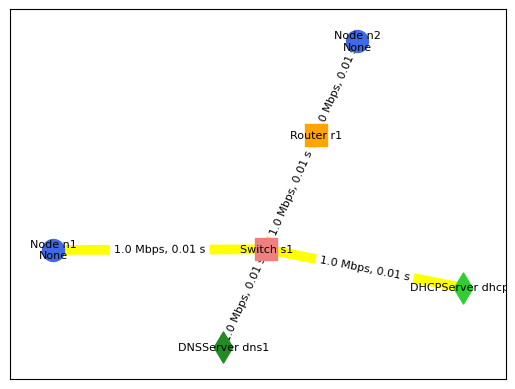

Node n1 sending DHCP DISCOVER (attempt 1/3)
DHCP Server dhcp1 offering IP 192.168.1.1/24 to client 48:08:d0:ea:06:f6
Node n1 sending DHCP REQUEST for IP 192.168.1.1/24
Node n1 has been assigned the IP address 192.168.1.1/24.
Node n1 has been assigned the DNS server IP address 192.168.1.200/24.
[HTTPClient] サーバURLからIPを解決しています: www.example.com
Node n1 sending DNS query for www.example.com
[HTTPClient] 接続後にファイルを取得します: index.html
DNS resolved: www.example.com -> 192.168.2.1/24
[HTTPClient] 解決されたIP: 192.168.2.1/24
[HTTPClient] TCP接続を要求しています: 192.168.2.1/24 80
Initiating TCP handshake: Sending SYN to 192.168.2.1/24:80
Sending TCP packet to 192.168.2.1/24:80 Flags: SYN Seq:None Ack:None
Processing TCP packet from 192.168.1.1/24:1024 to 192.168.2.1/24:80
TCP flags: SYN
Sending TCP packet to 192.168.1.1/24:1024 Flags: SYN,ACK Seq:None Ack:None
Processing TCP packet from 192.168.2.1/24:80 to 192.168.1.1/24:1024
TCP flags: SYN,ACK
TCP connection state updated to ESTABLISHED for ('192.168.2.1/24',

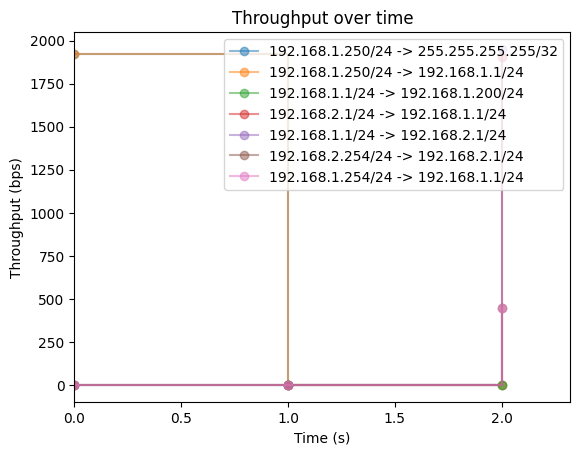

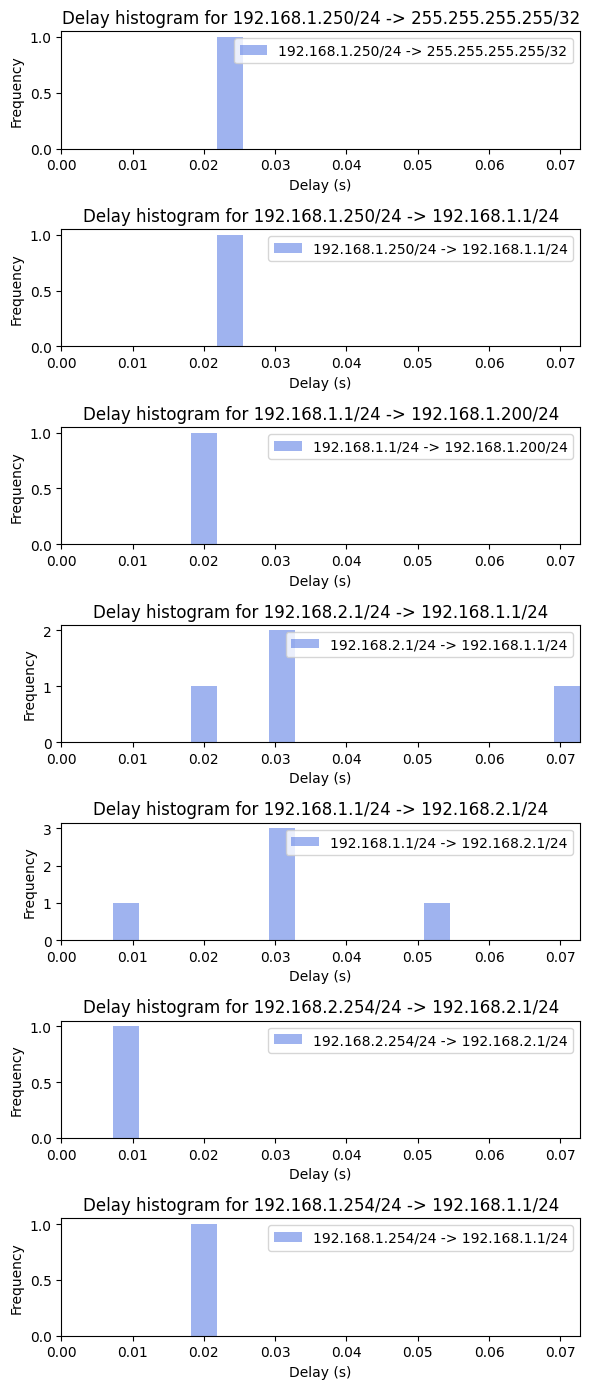

In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')
%cd network-simulator

from sec14b.NetworkEventScheduler import NetworkEventScheduler
from sec14b.Node import Node
from sec14b.Switch import Switch
from sec14b.Router import Router
from sec14b.Server import DNSServer, DHCPServer
from sec14b.Link import Link
from sec14b.Application import DnsClient, DhcpClient, UDPApp, FTPClient, FTPServer, HTTPClient, HTTPServer

nes = NetworkEventScheduler(seed=7, log_enabled=True, verbose=False, tcp_verbose=True, link_verbose=False)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.0/24", network_event_scheduler=nes)  # DHCP利用
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)  # IPアドレスを静的に設定
switch1 = Switch(node_id="s1", ip_address="192.168.1.240/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "192.168.2.254/24"], network_event_scheduler=nes)
dns1 = DNSServer(node_id="dns1", ip_address="192.168.1.200/24", network_event_scheduler=nes)
dhcp1 = DHCPServer(node_id="dhcp1", ip_address="192.168.1.250/24", dns_server_ip="192.168.1.200/24", start_cidr="192.168.1.0/24", network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=1000000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=1000000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(dns1, switch1, bandwidth=1000000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(dhcp1, switch1, bandwidth=1000000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link5 = Link(node2, router1, bandwidth=1000000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# DNSサーバに対してDNSレコード設定
dns1.add_dns_record("www.example.com", "192.168.2.1/24")

# DHCPサーバに対して使用済みIPアドレス登録
used_ips = ["192.168.1.240/24", "192.168.1.254/24", "192.168.1.200/24", "192.168.1.250/24"]
dhcp1.mark_ips_as_used(used_ips)

# HTTPサーバの設定
shared_files = {
    "index.html": b"Welcome to example.com!",
    "test.txt": b"This is a test file.",
    "large.dat": b"X" * 10000  # 10KB file for testing
}
http_server = HTTPServer(node2, shared_files, verbose=True)
node2.register_application(80, "TCP", http_server)  # HTTPサーバをApplicationManagerに登録

# HTTPクライアントの設定
http_client = HTTPClient(node1, verbose=True)
node1.register_application(0, "TCP", http_client)  # HTTPクライアントをApplicationManagerに登録

def start_http_download():
    http_client.connect(server_url="www.example.com")
    http_client.get_file("index.html")

# HTTPダウンロードを2秒後に開始
nes.schedule_event(2.0, start_http_download)

# イベントスケジューラを実行
nes.run_until(10.0)

# フォワーディングテーブルやルーティングテーブルを確認
node1.print_arp_table()
node1.print_url_to_ip_mapping()
node1.print_tcp_connections()
router1.print_arp_table()
router1.print_routing_table()
node2.print_arp_table()
node2.print_tcp_connections()

# 結果を確認
nes.generate_summary(nes.packet_logs)
nes.generate_throughput_graph(nes.packet_logs)
nes.generate_delay_histogram(nes.packet_logs)
#nes.plot_cwnd_log()


### 演習課題1：基本的なファイル転送

#### 目的
FTPクライアントの基本的な使い方、ファイル転送の仕組みを確認。

#### 課題の概要
以下のコードを参考に、FTPサーバに新しいファイル（"test.txt"）を追加し、クライアントからそのファイルを取得してみましょう：

```python
### サーバ側の準備
shared_files = {
    "test.txt": "test.txt": b"This is a test file for exercise 1. " * 100
}
ftp_server = FTPServer(node2, shared_files, verbose=True)

### クライアント側の操作
ftp_client = FTPClient(node1, verbose=True)
ftp_client.connect("192.168.2.1", 21)
ftp_client.retrieve_file("test.txt")
```

### 演習課題2：複数ファイルの転送

#### 目的
複数ファイルの転送方法を理解する。

#### 課題
以下のように複数のファイルを用意し、順番に転送してみましょう：

```python
### サーバ側の準備
shared_files = {
    "file1.txt": b"Content of file 1",
    "file2.txt": b"Content of file 2",
    "file3.txt": b"Content of file 3"
}
ftp_server = FTPServer(node2, shared_files, verbose=True)

### クライアント側の操作
ftp_client = FTPClient(node1, verbose=True)
ftp_client.connect("192.168.2.1", 21)

### 複数ファイルの転送
files_to_retrieve = ["file1.txt", "file2.txt", "file3.txt"]
for filename in files_to_retrieve:
    ftp_client.retrieve_file(filename)
```

### 演習3：ファイル取得
#### 目的
HTTPクライアントとサーバの基本的な使い方とファイル転送の仕組みを確認する。

#### 課題
以下のコードを参考に、HTTPサーバに新しいファイルを追加し、クライアントからそのファイルを取得してみましょう：

```python
# サーバ側の準備
shared_files = {
    "test.html": b"<html><body>This is a test page</body></html>"
}
http_server = HTTPServer(node2, shared_files, verbose=True)

# クライアント側の操作
http_client = HTTPClient(node1, verbose=True)
http_client.connect("192.168.2.1", 80)
http_client.get_file("test.html")
```

## 本章のまとめ

本章では、FTPとHTTPを題材にして、アプリケーション層のプロトコルを実装しました。
クライアントとサーバ間で、TCPハンドシェイクに続いてプロトコルごとのコネクション確立および状態遷移を行い、具体的なファイルとしてデータを送受信する流れを模擬できるようになりました。
ここまでに学習・実装してきたIPやTCPなどをベースとして、ようやく実際のデータ転送ができるところまで到達したと言えます。
実際のファイルをコンピュータ上で転送することも可能なので、ぜひ試してみてください。
